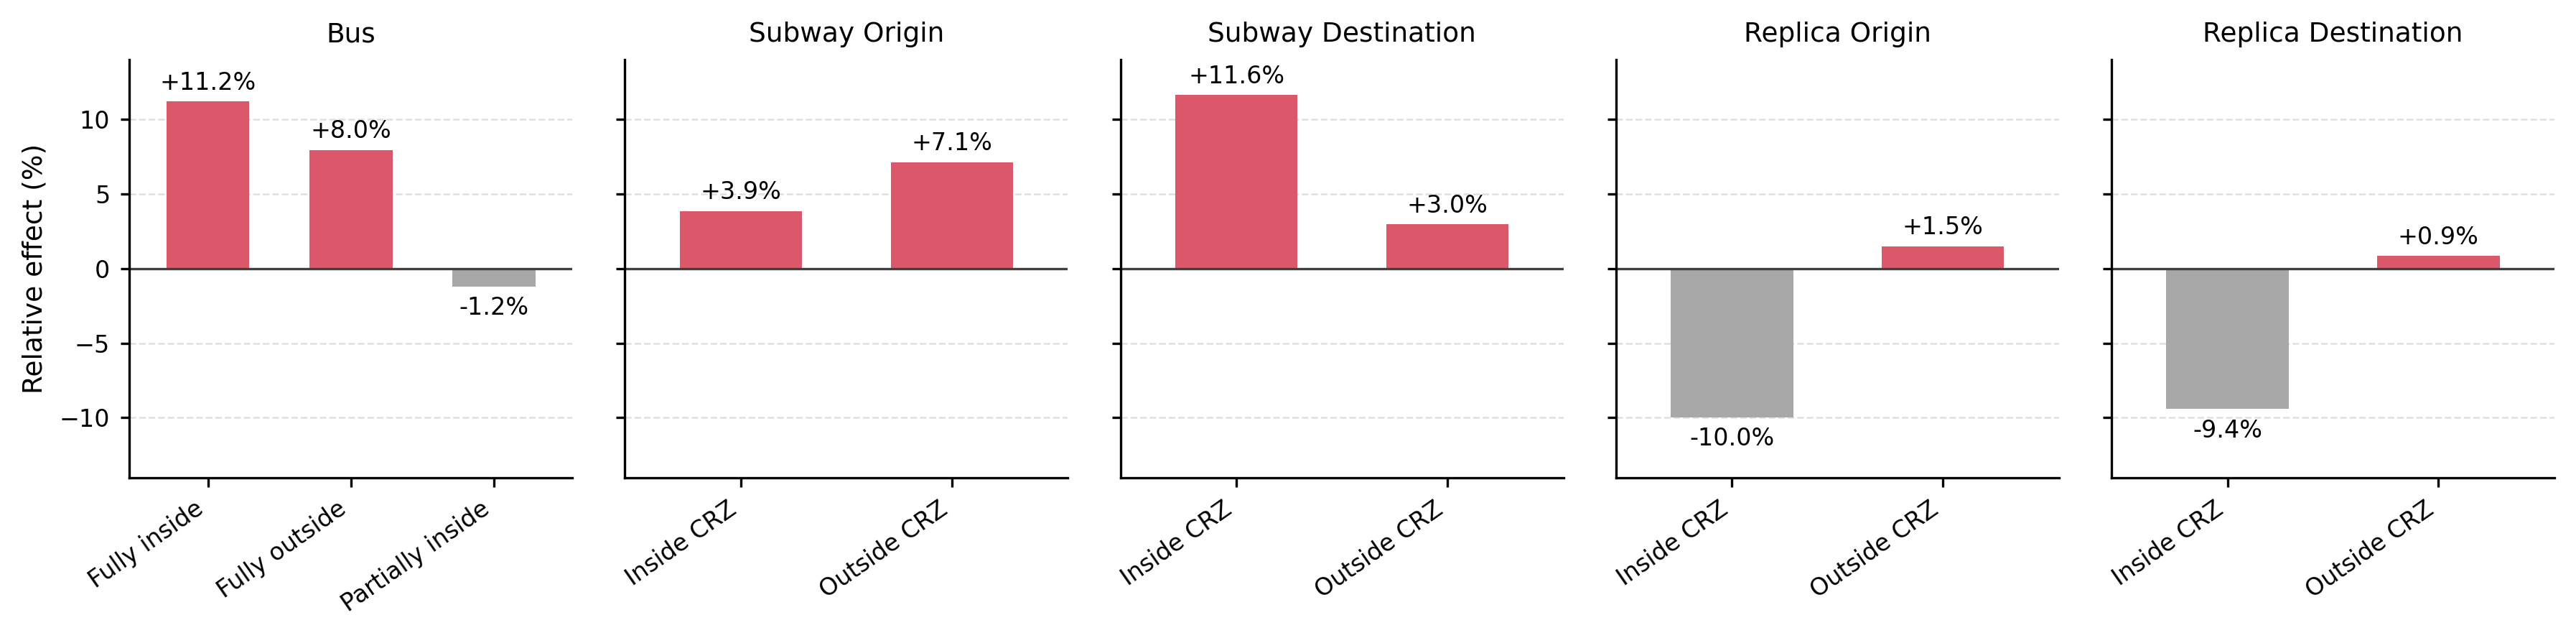

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

data = [
    ["Bus", "All", "Fully inside", 10, 8, 2, 41206, 22436, 11.21],
    ["Bus", "All", "Fully outside", 382, 282, 40, 39260, 26680, 7.95],
    ["Bus", "All", "Partially inside", 58, 26, 20, -9022, 4965, -1.21],
    ["Subway", "Origin", "Inside CRZ", 89, 57, 20, 51126, 39066, 3.85],
    ["Subway", "Origin", "Outside CRZ", 335, 229, 63, 55760, 27637, 7.13],
    ["Subway", "Destination", "Inside CRZ", 89, 41, 44, 142740, -9993, 11.63],
    ["Subway", "Destination", "Outside CRZ", 335, 108, 212, 24329, -47911, 2.98],
    ["Replica", "Origin", "Inside CRZ", 110, 20, 84, -67131, -51771, -9.97],
    ["Replica", "Origin", "Outside CRZ", 1848, 843, 784, 2871, 370, 1.49],
    ["Replica", "Destination", "Inside CRZ", 110, 20, 83, -59473, -47124, -9.42],
    ["Replica", "Destination", "Outside CRZ", 1848, 787, 843, 1567, -368, 0.86],
]

df = pd.DataFrame(data, columns=[
    "Mode", "Direction", "Spatial class", "Units", "Sig. positive",
    "Sig. negative", "Mean ATT", "Median ATT", "Relative effect"
])

df["Panel"] = df["Mode"] + " " + df["Direction"]
df.loc[df["Mode"] == "Bus", "Panel"] = "Bus"

panel_order = [
    "Bus",
    "Subway Origin",
    "Subway Destination",
    "Replica Origin",
    "Replica Destination"
]

fig, axes = plt.subplots(
    1, 5,
    figsize=(12, 3),
    sharey=True,
    dpi = 300
)

positive_color = "#DB586A"
negative_color = "#A8A8A8"

for ax, panel in zip(axes, panel_order):
    sub = df[df["Panel"] == panel].copy()
    x = np.arange(len(sub))
    y = sub["Relative effect"].values
    colors = [positive_color if v >= 0 else negative_color for v in y]

    bars = ax.bar(
        x,
        y,
        width=0.58,
        color=colors,
        edgecolor="none"
    )

    ax.axhline(0, color="0.25", linewidth=0.8)
    ax.yaxis.grid(True, color="0.88", linewidth=0.6, linestyle="--")
    ax.set_axisbelow(True)

    for bar, value in zip(bars, y):
        offset = 0.45 if value >= 0 else -0.65
        va = "bottom" if value >= 0 else "top"
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + offset,
            f"{value:+.1f}%",
            ha="center",
            va=va,
            fontsize=8
        )

    ax.set_title(panel, pad=6)
    ax.set_xticks(x)
    ax.set_xticklabels(sub["Spatial class"], rotation=35, ha="right")
    ax.set_xlim(-0.55, len(sub) - 0.45)
    ax.set_ylim(-14, 14)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    ax.tick_params(axis="both", width=0.8, length=3)

axes[0].set_ylabel("Relative effect (%)")

plt.tight_layout(w_pad=1.0)
plt.savefig("att_timesfm_qrcal_intercept_nature_style.png", dpi=600, bbox_inches="tight")
plt.savefig("att_timesfm_qrcal_intercept_nature_style.pdf", bbox_inches="tight")
plt.show()